# 3. Instrumental variables: Card's college proximity data

Does more education raise wages? Education is confounded (ability, family background...), so use an instrument:
growing up near a 4-year college (`nearc4`) nudges people toward more education but plausibly affects wages
only through education.

- instrument Z: `nearc4`
- treatment A: `educ12`, more than 12 years of education
- outcome Y: `lwage`, log of wage

The course used the `ivpack` package, which has been removed from CRAN; `fixest` does the two-stage least
squares here.

In [1]:
source("setup.R")
use_packages("fixest")

load("data/card.data.rda")  # creates card.data
card.data$educ12 <- card.data$educ > 12
head(card.data)

,id,nearc2,nearc4,educ,age,fatheduc,motheduc,weight,momdad14,sinmom14,⋯,enroll,KWW,IQ,married,libcrd14,exper,lwage,expersq,region,educ12
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<lgl>
1,2,0,0,7,29,NA,NA,158413,1,0,⋯,0,15,NA,1,0,16,6.306275,256,661,FALSE
2,3,0,0,12,27,8,8,380166,1,0,⋯,0,35,93,1,1,9,6.175867,81,661,FALSE
3,4,0,0,12,34,14,12,367470,1,0,⋯,0,42,103,1,1,16,6.580639,256,661,FALSE
4,5,1,1,11,27,11,12,380166,1,0,⋯,0,25,88,1,1,10,5.521461,100,662,FALSE
5,6,1,1,12,34,8,7,367470,1,0,⋯,0,34,108,1,0,16,6.591674,256,662,FALSE
6,7,1,1,12,26,9,12,380166,1,0,⋯,0,38,85,1,1,8,6.214608,64,662,FALSE


## Summary statistics and instrument strength

[1] 0.6820598

0        1 
12.69801 13.52703

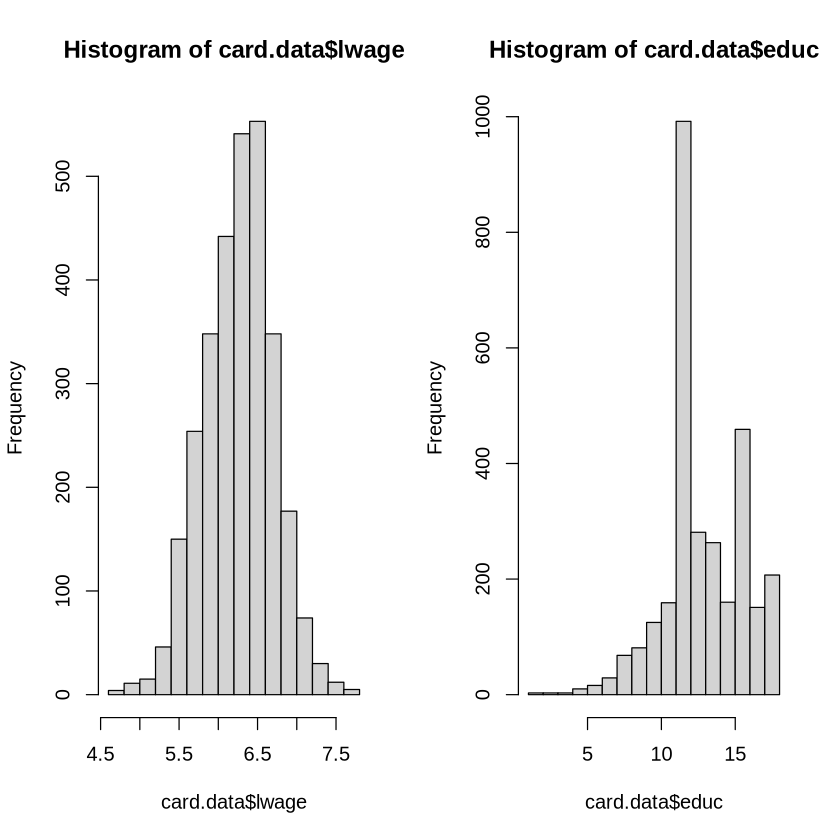

In [2]:
mean(card.data$nearc4)
par(mfrow = c(1, 2))
hist(card.data$lwage)
hist(card.data$educ)

# is the IV associated with the treatment? (strength of the IV)
with(card.data, tapply(educ, nearc4, mean))

## Complier average causal effect

CACE = ITT / proportion of compliers: the effect of the instrument on the outcome, scaled by its effect on
treatment.

In [3]:
near <- card.data$nearc4 == 1

# proportion of compliers
propcomp <- mean(card.data$educ12[near]) - mean(card.data$educ12[!near])
# intention to treat effect
itt <- mean(card.data$lwage[near]) - mean(card.data$lwage[!near])

c(proportion_of_compliers = propcomp, ITT = itt, causal_effect = itt / propcomp)

proportion_of_compliers                     ITT           causal_effect 
              0.1219293               0.1559075               1.2786716

## Two stage least squares

By hand: stage 1 regresses A on Z; stage 2 regresses Y on the predicted A. The slope matches the CACE above.

In [4]:
s1 <- lm(educ12 ~ nearc4, data = card.data)
predtx <- predict(s1, type = "response")
table(predtx)

lm(card.data$lwage ~ predtx)

predtx
0.422152560083594 0.544081831466147 
              957              2053 


Call:
lm(formula = card.data$lwage ~ predtx)

Coefficients:
(Intercept)       predtx  
      5.616        1.279  


With `fixest`, which also gives correct standard errors (the by-hand stage 2 standard errors ignore the
first stage):

In [5]:
est_iv <- feols(lwage ~ 1 | educ12 ~ nearc4, data = card.data)
est_iv

TSLS estimation: Second stage
|- D.V.   : lwage
|- Endo.  : educ12
|- Instr. : nearc4
Dep. Var.: lwage
Observations: 3,010
Standard-errors: IID 
               Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)     5.61570   0.113294 49.56754  < 2.2e-16 ***
fit_educ12TRUE  1.27867   0.222802  5.73905 1.0469e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.693825   Adj. R2: 0.026448
F-test (1st stage), educ12TRUE: stat = 39.301, p = 4.151e-10, on 1 and 3,008 DoF.
                    Wu-Hausman: stat = 62.895, p = 3.047e-15, on 1 and 3,007 DoF.

Adding experience and region controls (the `ivpack` example in the course):

In [6]:
feols(lwage ~ exper + reg661 + reg662 + reg663 + reg664 + reg665 + reg666 + reg667 + reg668 | educ12 ~ nearc4,
      data = card.data, vcov = "hetero")

TSLS estimation: Second stage
|- D.V.   : lwage
|- Endo.  : educ12
|- Instr. : nearc4
Dep. Var.: lwage
Observations: 3,010
Standard-errors: Heteroskedasticity-robust 
                Estimate Std. Error   t value   Pr(>|t|)    
(Intercept)     4.950242   0.363702 13.610714  < 2.2e-16 ***
fit_educ12TRUE  1.203660   0.305107  3.945047 8.1613e-05 ***
exper           0.081452   0.019476  4.182141 2.9705e-05 ***
reg661          0.009228   0.073002  0.126408 8.9942e-01    
reg662          0.092530   0.056208  1.646207 9.9826e-02 .  
reg663          0.109208   0.055091  1.982304 4.7536e-02 *  
reg664         -0.023602   0.063093 -0.374083 7.0837e-01    
reg665         -0.111628   0.066066 -1.689646 9.1200e-02 .  
reg666         -0.135042   0.070581 -1.913286 5.5807e-02 .  
reg667         -0.088088   0.068640 -1.283335 1.9947e-01    
reg668         -0.256740   0.071990 -3.566326 3.6768e-04 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 0.569855   Adj. R2: 0.092967